# Plot Sternberg model firing rates

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-04-23 10:59:55.638678: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 10:59:55.647876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 10:59:55.657494: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 10:59:55.660259: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 10:59:55.667618: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

7
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


In [4]:
# find folder names within model directory

perfs = []
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    load1_idx = np.where(trial_labels[:,0] == 1)[0]
    load3_idx = np.where(trial_labels[:,0] == 3)[0]
    perfs.append([np.mean(trial_perfs[load1_idx]), np.mean(trial_perfs[load3_idx])])
    print(f'Model {model_name}, performance: {perfs[i]}')


Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205, performance: [0.8541666666666666, 0.6006944444444444]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441, performance: [0.7916666666666666, 0.5520833333333334]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957, performance: [0.75, 0.6909722222222222]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713, performance: [0.75, 0.7048611111111112]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959, performance: [0.75, 0.6666666666666666]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628, performance: [0.625, 0.6354166666666666]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058, performance: [0.7291666666666666, 0.6354166666666666]


In [5]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/settings_dict_delay200.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/bhv_dict_delay200.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205/neural_dict_delay200.pkl']


## plot rates

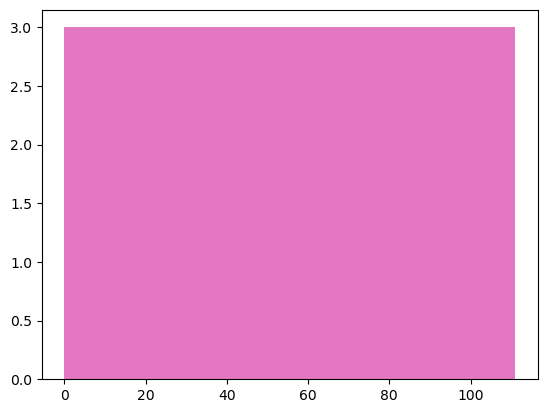

In [ ]:
for model_name in model_names:
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    all_models_dir=all_models_dir)

    stim_ids = trial_labels[:,2:]
    stim_ids = np.nan_to_num(stim_ids, nan=np.inf)
    trial_types, trial_idxs = np.unique(stim_ids, axis=0, return_inverse=True, equal_nan=True)
    match = trial_labels[:,1]
    _ = plt.hist(trial_idxs, bins=112)

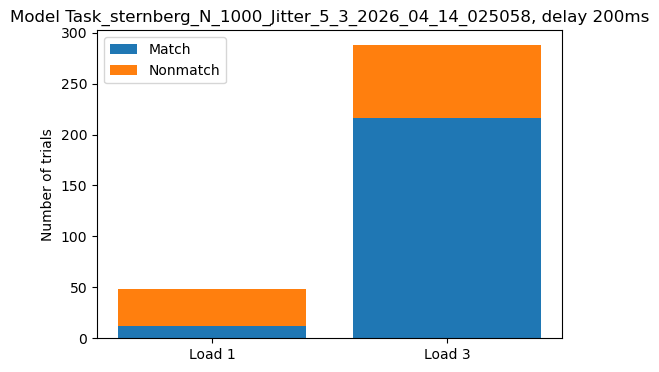

In [12]:
# how many of stim ids are match vs nonmatch for each load

# bar plot of number of match/mismatch for each load
low_match_idx = np.where((trial_labels[:,0] == 1) & (trial_labels[:,1] == 1))[0]
low_nonmatch_idx = np.where((trial_labels[:,0] == 1) & (trial_labels[:,1] == -1))[0]
high_match_idx = np.where((trial_labels[:,0] == 3) & (trial_labels[:,1] == 1))[0]
high_nonmatch_idx = np.where((trial_labels[:,0] == 3) & (trial_labels[:,1] == -1))[0]

plt.figure(figsize=(6,4))
plt.bar(['Load 1', 'Load 3'], [len(low_match_idx), len(high_match_idx)], label='Match')
plt.bar(['Load 1', 'Load 3'], [len(low_nonmatch_idx), len(high_nonmatch_idx)], bottom=[len(low_match_idx), len(high_match_idx)], label='Nonmatch')
plt.ylabel('Number of trials')
plt.title(f'Model {model_name}, delay {delay}ms')
plt.legend()
plt.show()

In [6]:
# behavioral data
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

# trial_labels is (load, match/mismatch)

(336, 6) (336,) (336, 450)


In [6]:
# neural data
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num,
                                            all_models_dir = all_models_dir, load_LFP=False)

In [ ]:
rates_data.shape # (num_trials, num_neurons, num_timepoints)

(200, 1000, 450)

In [7]:
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 200,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 3}

In [8]:
# behavioral data
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

# trial_labels is (load, match/mismatch)

(200, 6) (200,) (200, 450)


In [11]:
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
print(trial_types, trial_idxs)

[[1 0]
 [1 1]
 [3 0]
 [3 1]] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


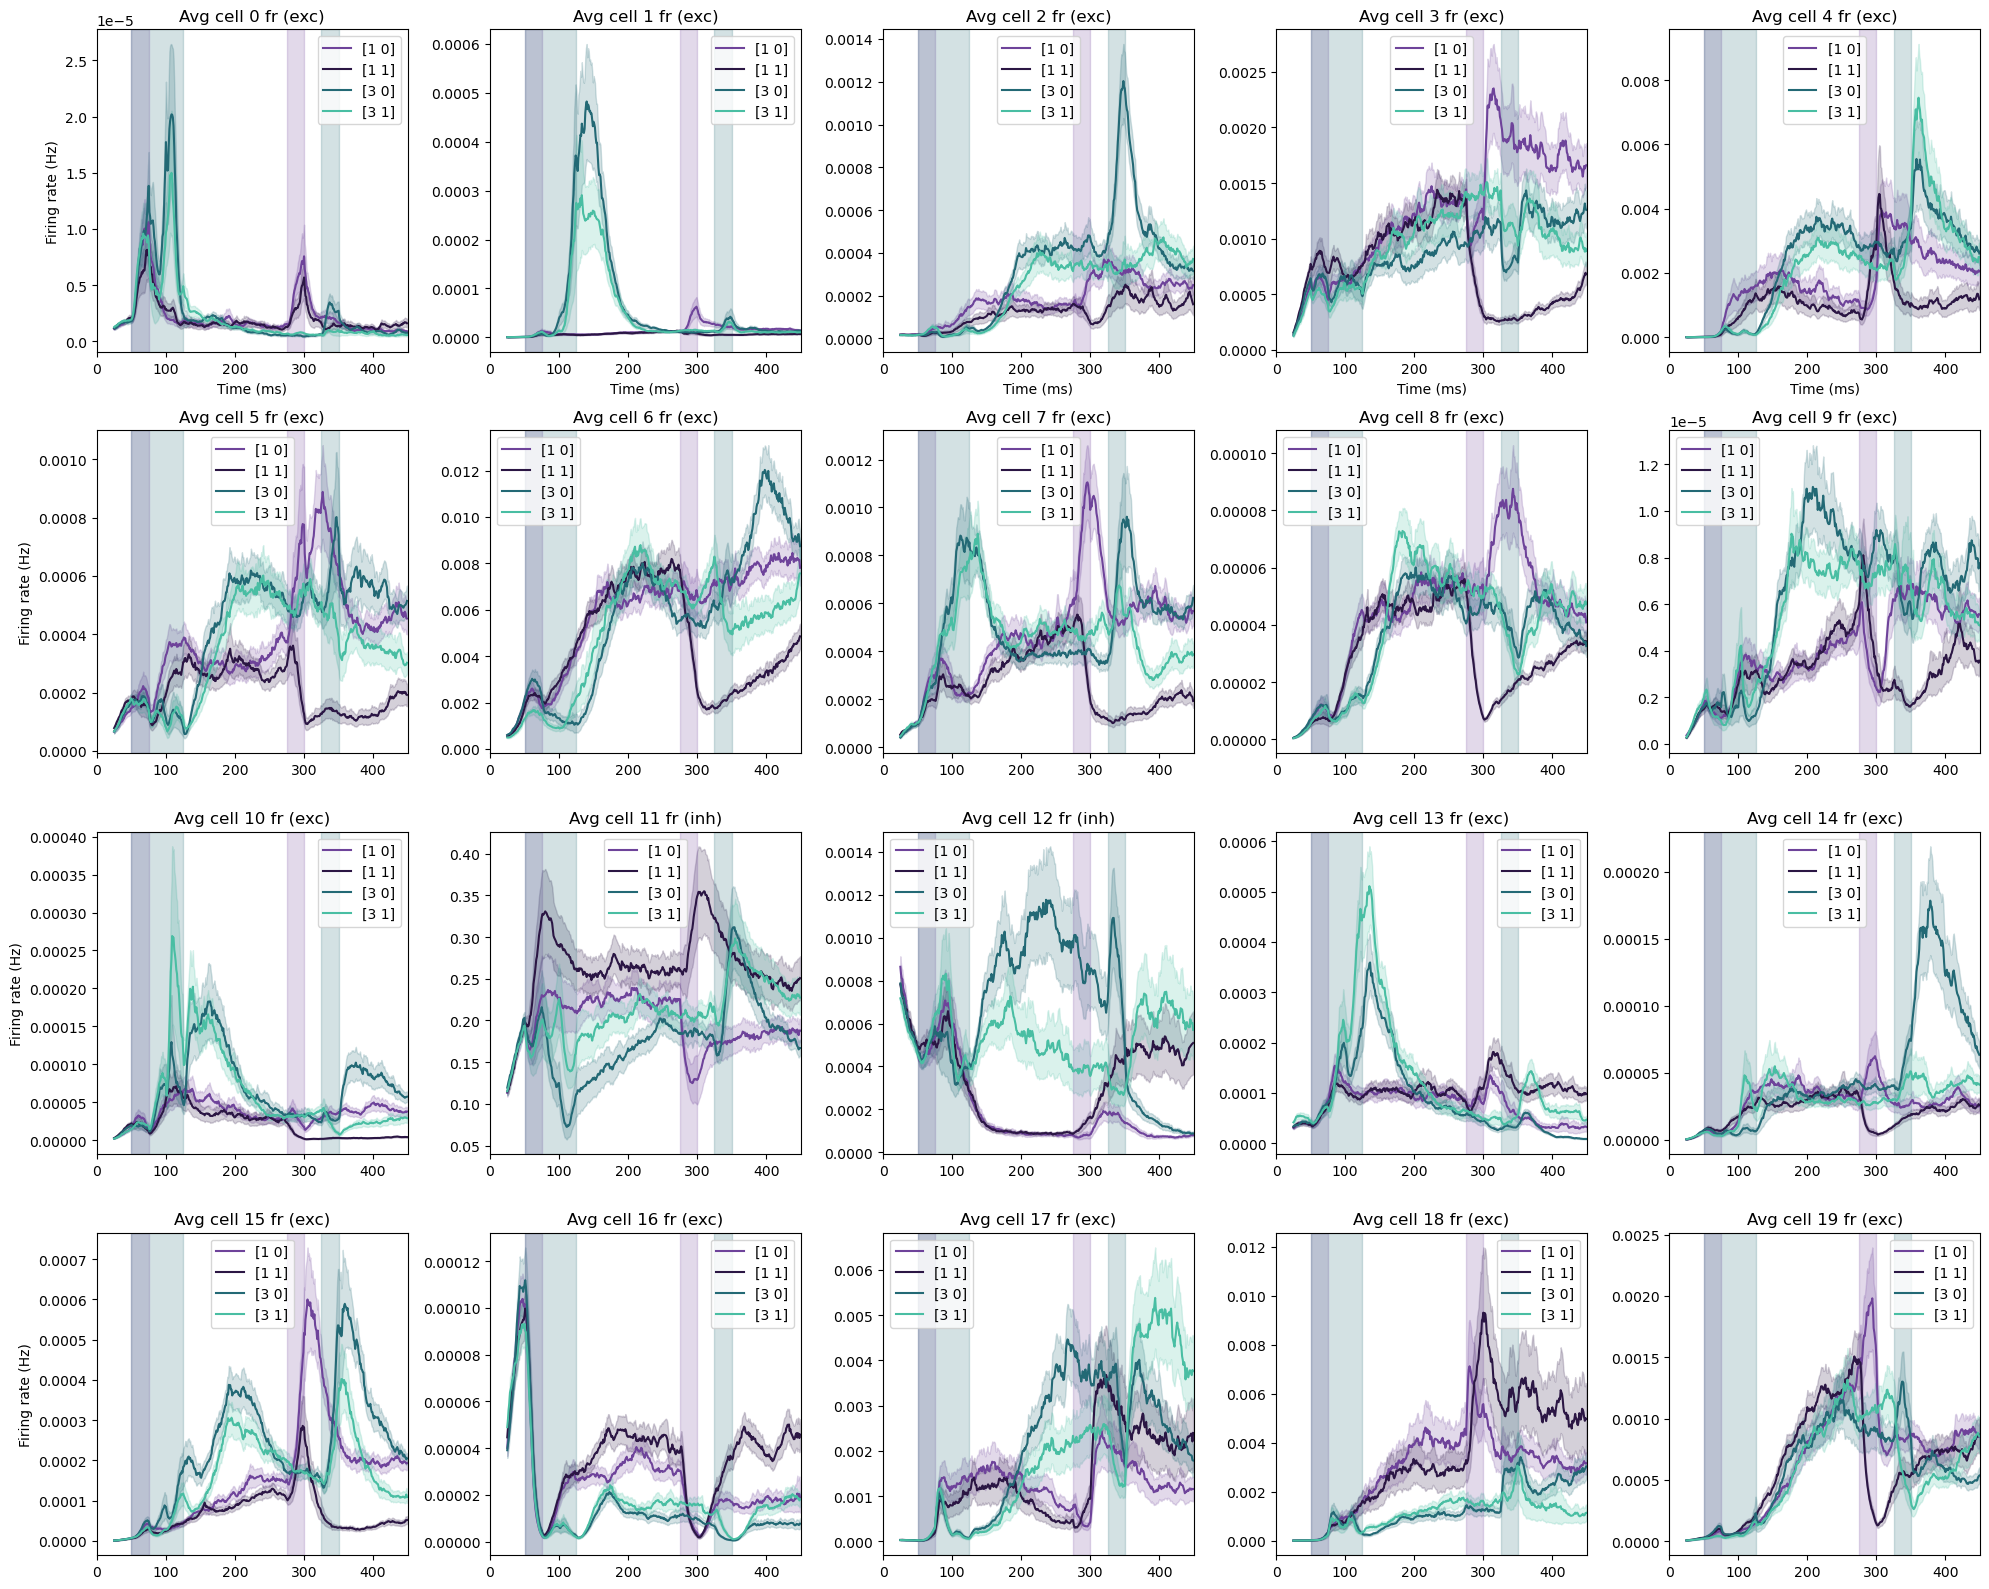

In [16]:
# let's take a look some neurons
import rate_neuron_utils as rn
importlib.reload(rn)

fig, axs = plt.subplots(4,5, figsize=(20,16))
axs = axs.flatten()
for n_neuron in range(20):
    rn.plot_neuron_rates(model_name, n_neuron, condn_phrase, condn_num, rates_data = rates_data, 
                         cut_off=25, ax=axs[n_neuron],
                         all_models_dir=all_models_dir)
    # axs[n_neuron].set_title(f'Neuron {n_neuron}')

# remove axis labels besides the first row and first column
for i in range(4):
    for j in range(5):
        if i > 0:
            axs[i*5 + j].set_xlabel('')
        if j > 0:
            axs[i*5 + j].set_ylabel('')
        
plt.tight_layout()
plt.show()

## population activity

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
neuron_rates_pca = pca.fit_transform(rates_data[0, :, :]) # (num_neurons, num_timepoints) -> (num_neurons, 2)
sort_idx = np.argsort(neuron_rates_pca[:,0])

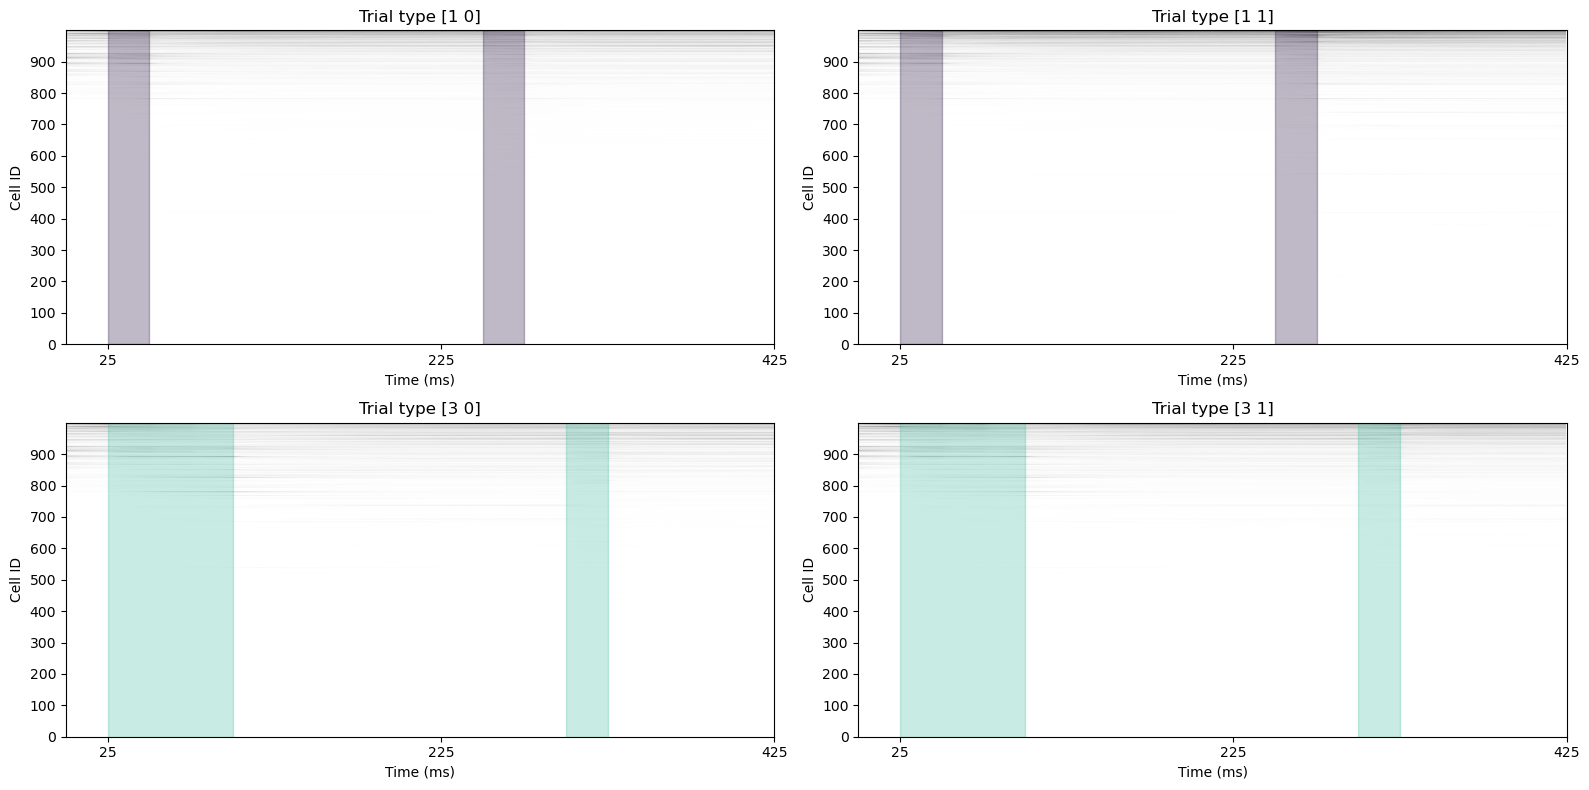

In [34]:
importlib.reload(rn)

rn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, 
                            rates_data = rates_data, sort=sort_idx,
                            cut_off=25, hlines=[], normalize=False,
                            all_models_dir=all_models_dir,
                            vmin=0, vmax=1, cmap='Greys')

In [9]:
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
# exc_bool = np.zeros(rates_data.shape[1], dtype=bool)
# exc_bool[exc_ind] = True
# inh_bool = np.zeros(rates_data.shape[1], dtype=bool)
# inh_bool[inh_ind] = True

/tmp/ipykernel_432634/332100195.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sort_idx[exc_ind], sort_idx[inh_ind]], labels=['Excitatory', 'Inhibitory'])


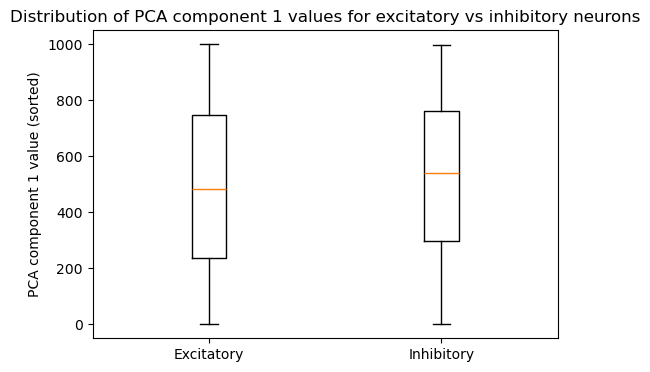

In [42]:
plt.figure(figsize=(6,4))
plt.boxplot([sort_idx[exc_ind], sort_idx[inh_ind]], labels=['Excitatory', 'Inhibitory'])
plt.ylabel('PCA component 1 value (sorted)')
plt.title('Distribution of PCA component 1 values for excitatory vs inhibitory neurons')
plt.show()

In [46]:
# small test

trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
trial_pcs = []

pca = PCA(n_components=3).fit(rates_data[0, :, 25:].T) # fit PCA on all neurons' rates across time (after cut-off)
for i, trial_type in enumerate(trial_types):
    trial_mean_rate = np.mean(rates_data[trial_idxs == i, :, 25:], axis=0) # (num_neurons, num_timepoints)
    trial_pc = pca.transform(trial_mean_rate.T) # (num_timepoints, num_neurons) -> (num_timepoints, 3)
    trial_pcs.append(trial_pc)


In [49]:
trial_pcs[0].shape

(425, 3)

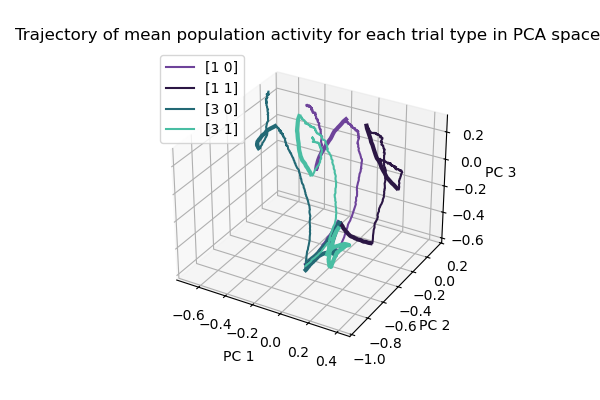

In [51]:
from mpl_toolkits.mplot3d import axes3d
# %matplotlib inline 
%matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')
for i, trial_type in enumerate(trial_types):
    ax.plot(trial_pcs[i][:,0], trial_pcs[i][:,1], trial_pcs[i][:,2], 
            label=f'{trial_type}', color=colors[i])
    load = trial_type[0]
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
            trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
            trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
            color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

In [54]:
delay_start

array([50, 25])

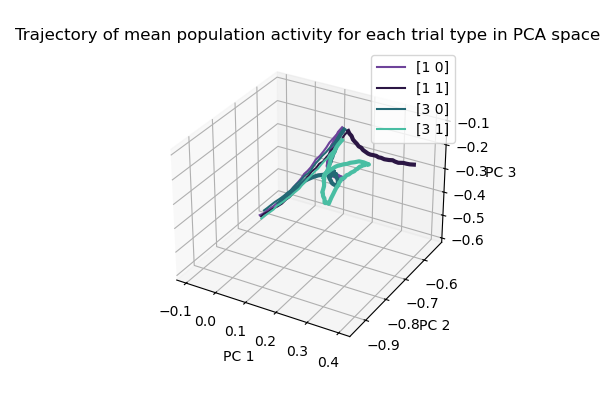

In [56]:
from mpl_toolkits.mplot3d import axes3d
# %matplotlib inline 
%matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')
for i, trial_type in enumerate(trial_types):
    load = trial_type[0]
    delay_start = int(settings['stim_on'] + settings['stim_dur']*load - 25)
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

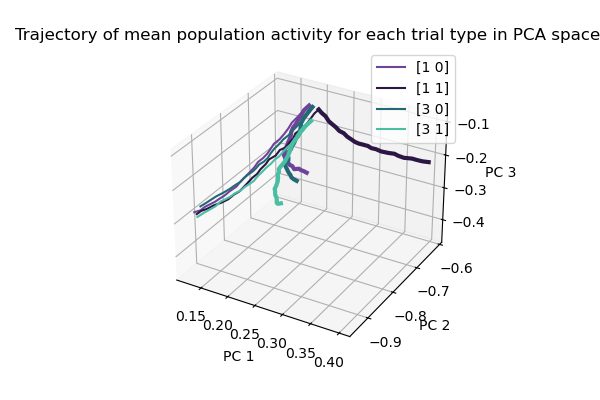

In [58]:
from mpl_toolkits.mplot3d import axes3d
# %matplotlib inline 
%matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')

delay_start = int(settings['stim_on'] + settings['stim_dur']*1 - 25)
for i, trial_type in enumerate(trial_types):
    load = 1
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

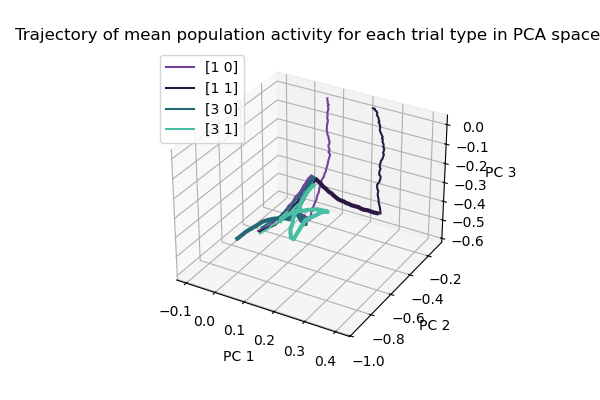

In [59]:
from mpl_toolkits.mplot3d import axes3d
# %matplotlib inline 
%matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')

delay_start = int(settings['stim_on'] + settings['stim_dur']*3 - 25)
for i, trial_type in enumerate(trial_types):
    load = trial_type[0]
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755318
PCA explained variance: [0.4515359  0.21548833 0.16214771], total: 0.8291719386657809
PCA explained variance: [0.47749151 0.18275389 0.14517343], total: 0.8054188269667377


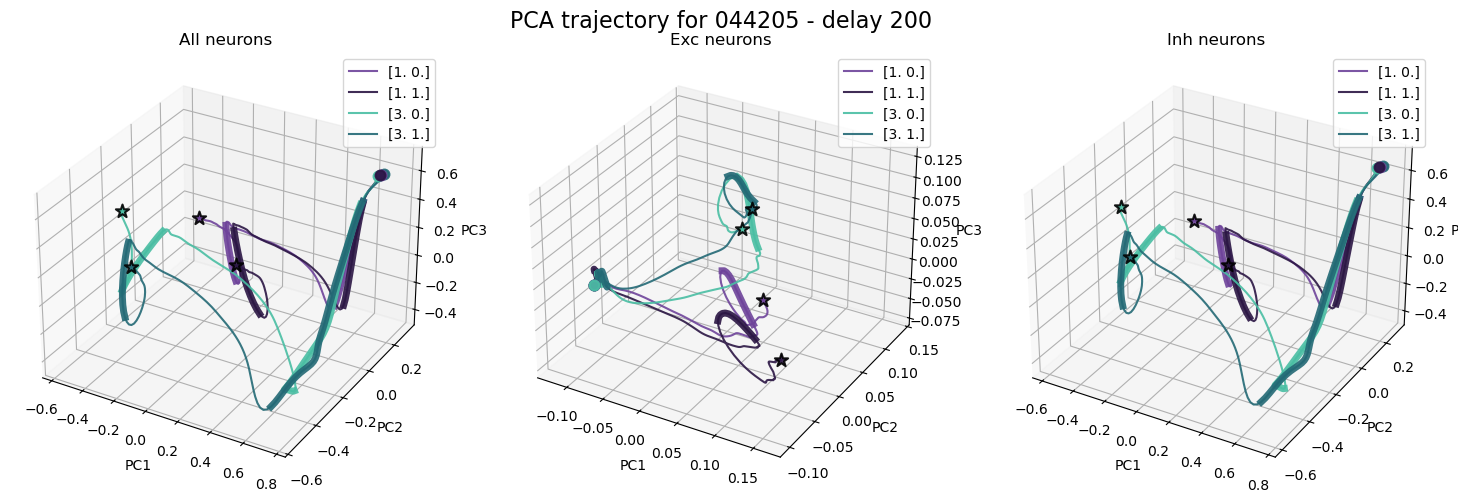

In [28]:
import population_utils as pu
importlib.reload(pu)
importlib.reload(ld)

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=None, rates_data=rates_data, cut_off=25, 
                   ds=2, sigma=5, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=25, 
                   ds=2, sigma=5, ax=ax2, title='Exc neurons',
                   all_models_dir=all_models_dir)
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=25,
                   ds=2, sigma=5, ax=ax3, title='Inh neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
rates_corr = rates_data[trial_perfs == 1,:,:]
rates_incorr = rates_data[trial_perfs == 0,:,:]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

Accuracy for 044205: 0.81
PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755318
PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755318


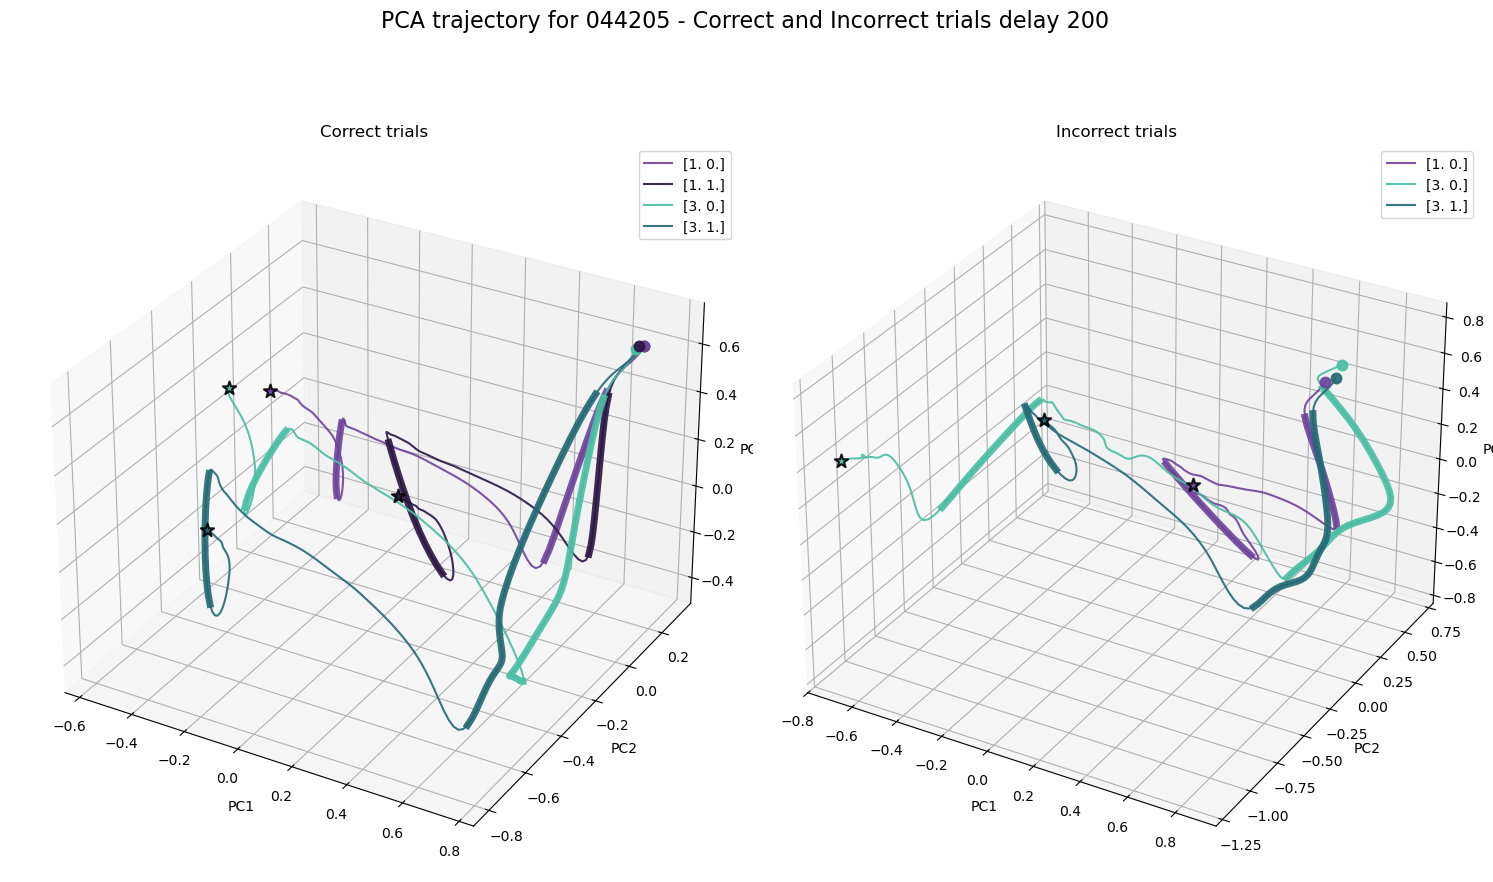

In [29]:
# plot correct and incorrect next to each other

print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()##

PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755312
PCA explained variance: [0.4515359  0.21548833 0.16214771], total: 0.82917193866578
PCA explained variance: [0.47749151 0.18275389 0.14517343], total: 0.8054188269667392


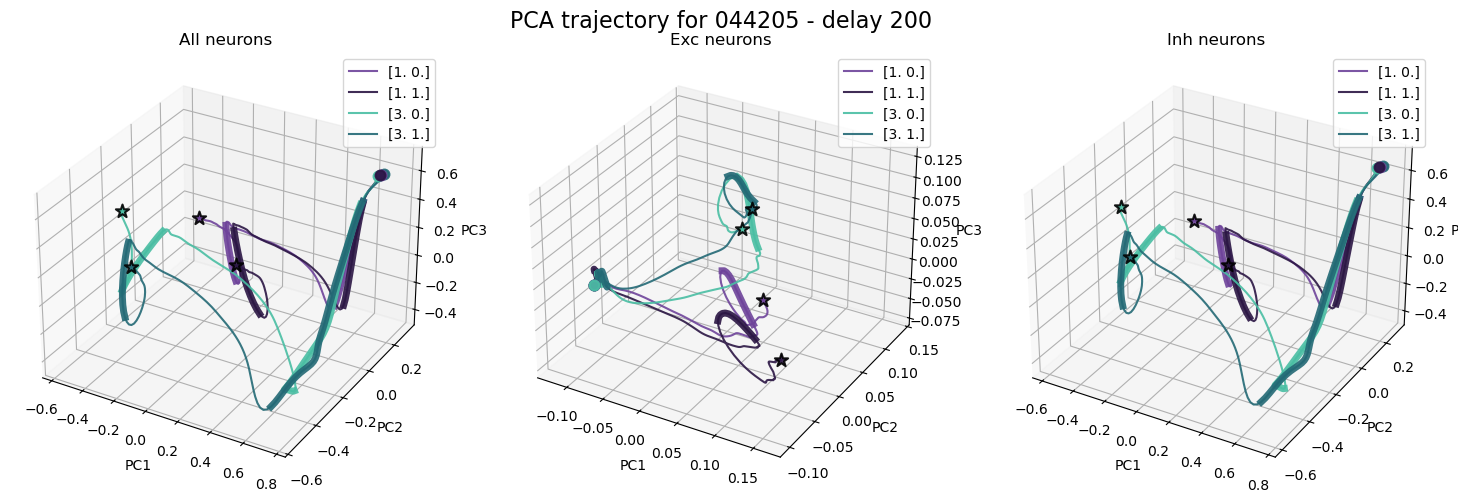

Accuracy for 044205: 0.81
PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755312
PCA explained variance: [0.47100819 0.18020463 0.14345492], total: 0.7946677436755312


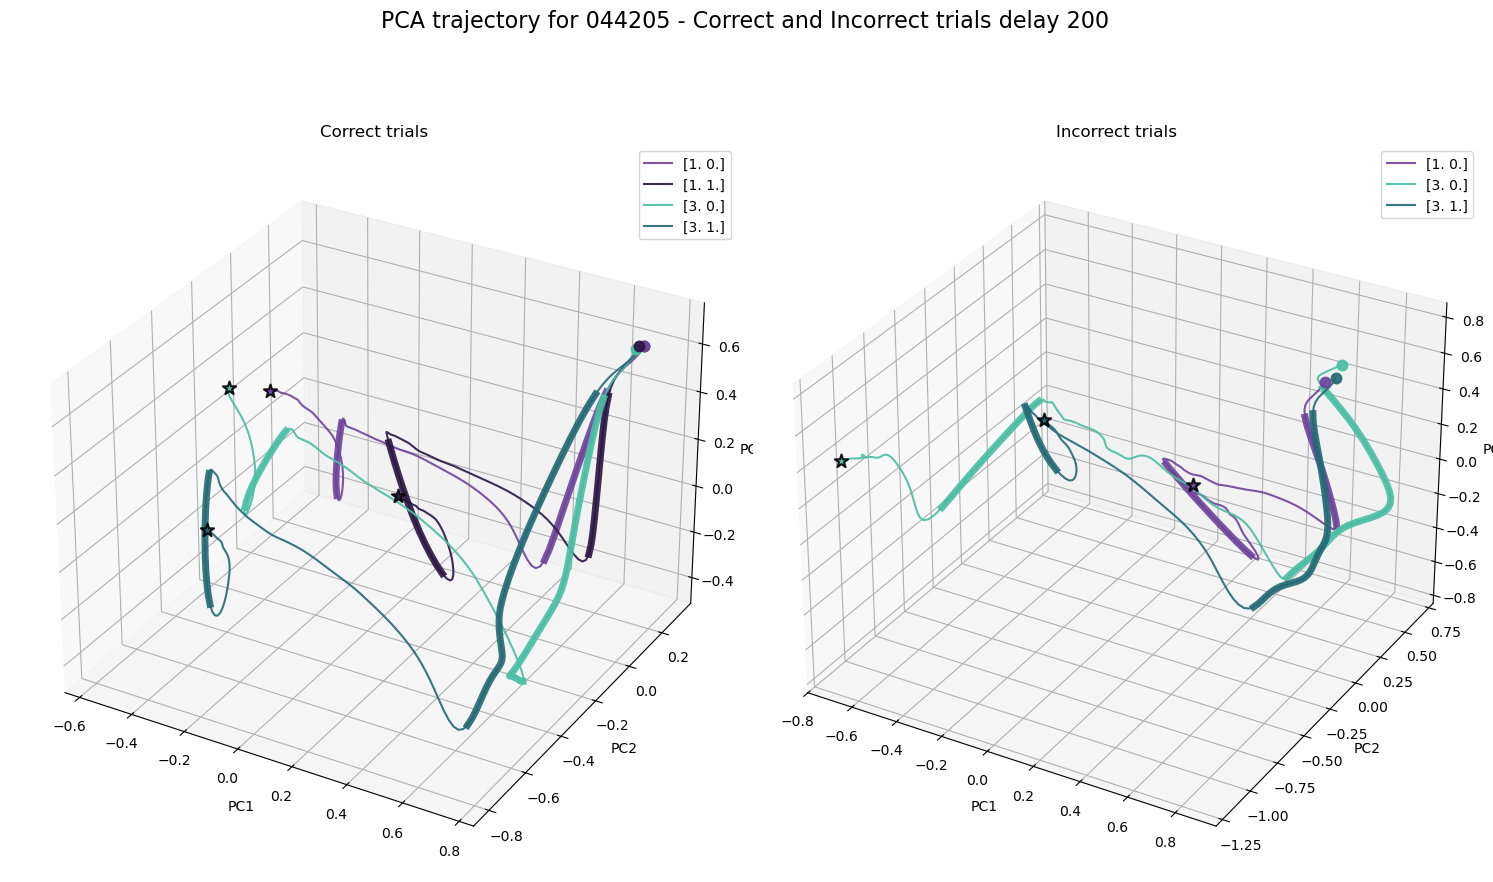

PCA explained variance: [0.47852404 0.19799896 0.16461687], total: 0.8411398676294677
PCA explained variance: [0.47685329 0.18894987 0.1795334 ], total: 0.8453365675739913
PCA explained variance: [0.50806282 0.22374037 0.14738977], total: 0.8791929633470439


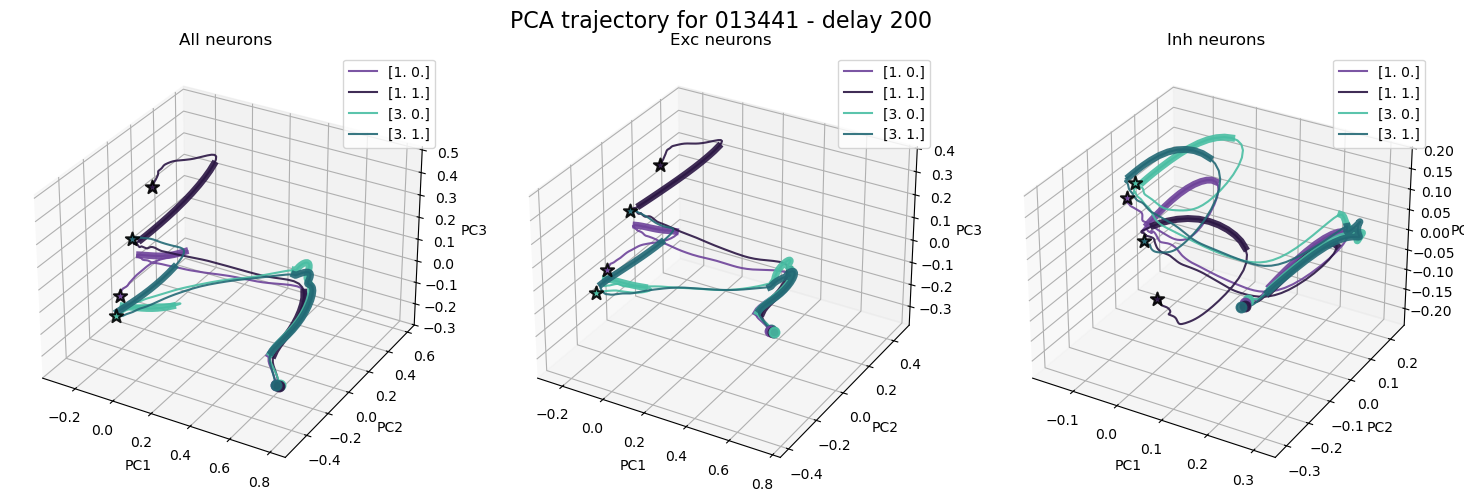

Accuracy for 013441: 0.81
PCA explained variance: [0.47852404 0.19799896 0.16461687], total: 0.8411398676294677
PCA explained variance: [0.47852404 0.19799896 0.16461687], total: 0.8411398676294677


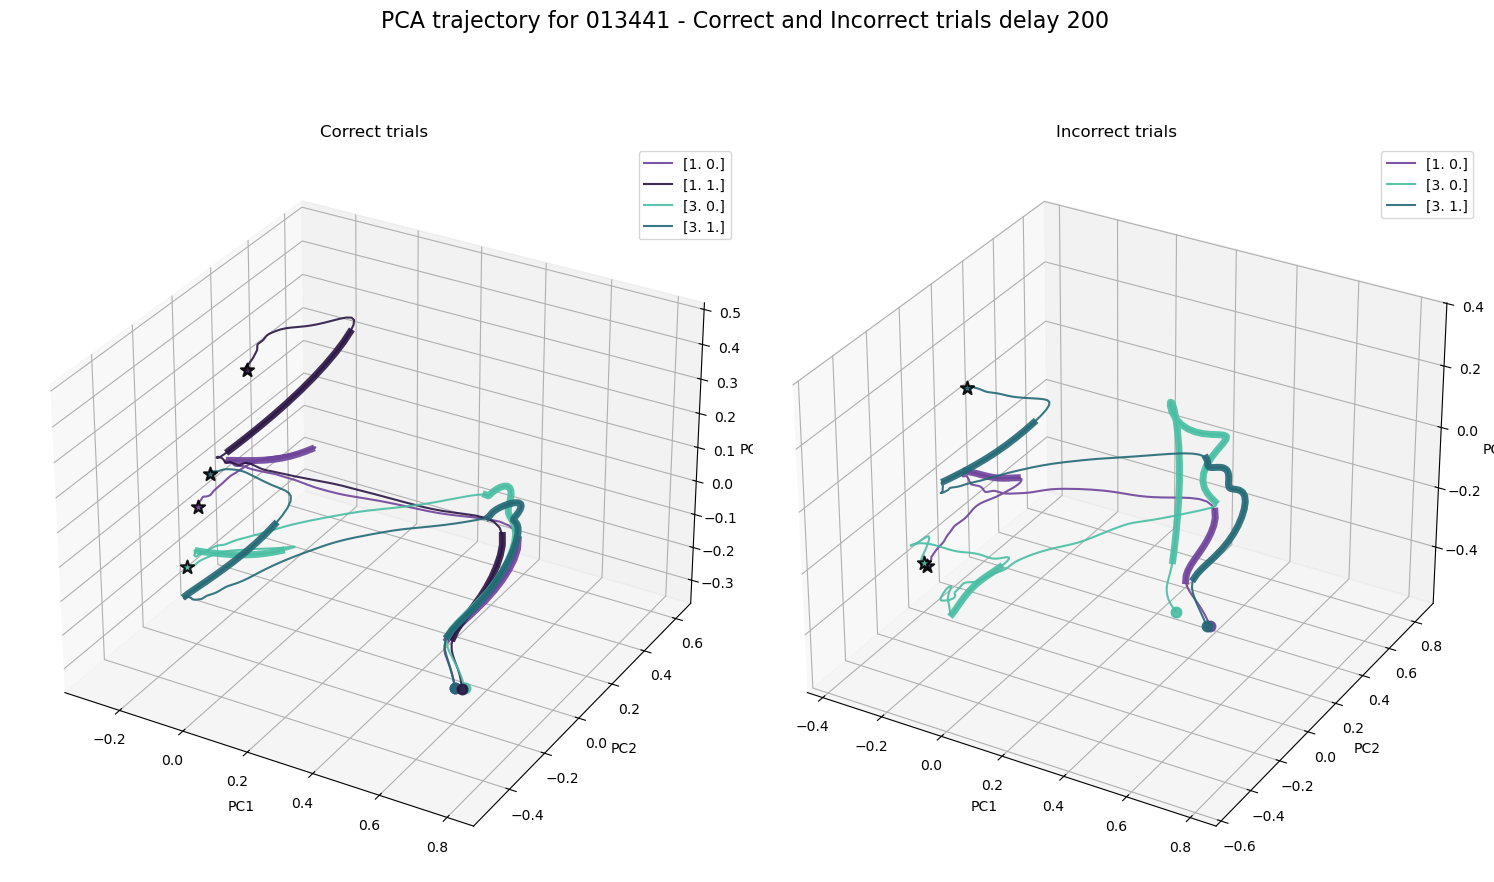

PCA explained variance: [0.46249453 0.22234902 0.12911418], total: 0.8139577256460099
PCA explained variance: [0.49137455 0.18700046 0.13692731], total: 0.815302331215262
PCA explained variance: [0.42049079 0.32203474 0.09228625], total: 0.8348117833586821


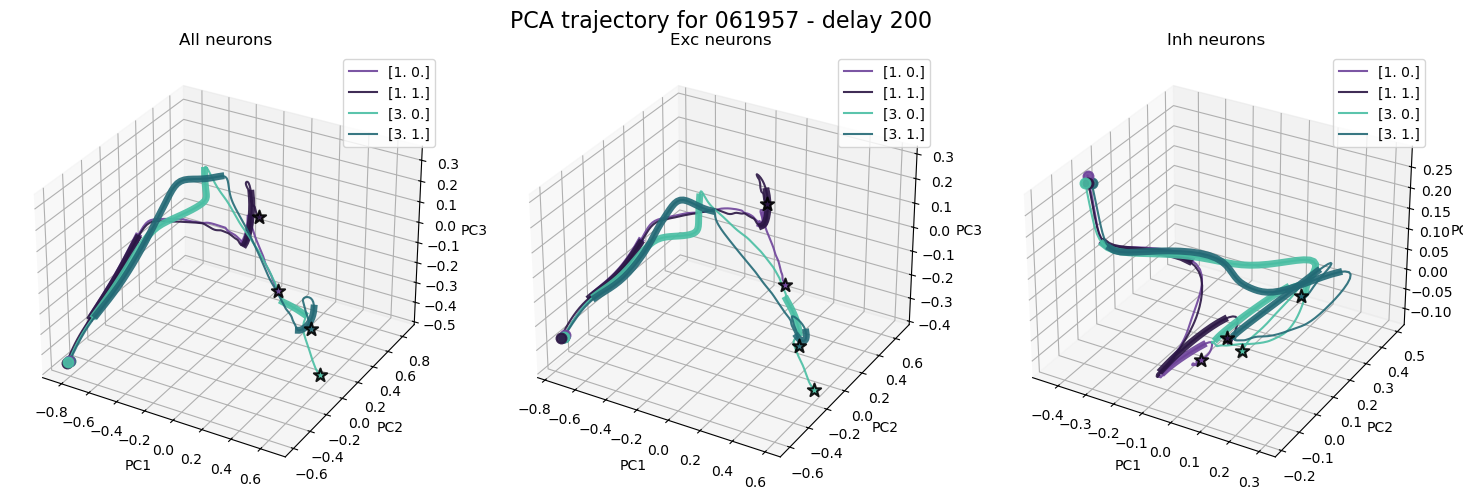

Accuracy for 061957: 0.81
PCA explained variance: [0.46249453 0.22234902 0.12911418], total: 0.8139577256460099
PCA explained variance: [0.46249453 0.22234902 0.12911418], total: 0.8139577256460099


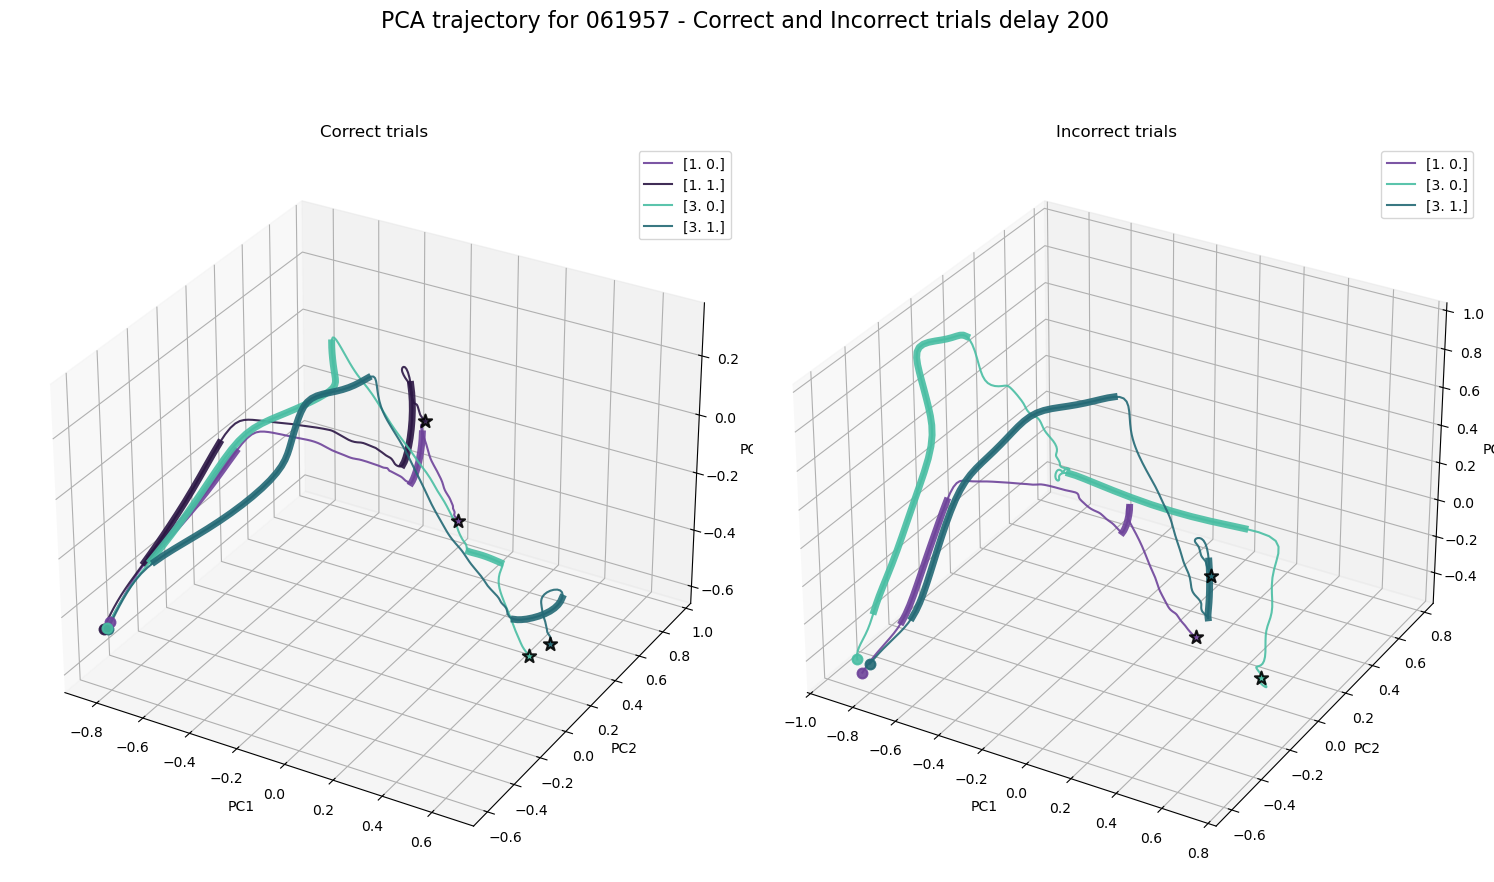

PCA explained variance: [0.58010894 0.1629999  0.10869445], total: 0.8518032902756437
PCA explained variance: [0.60619764 0.15418717 0.09988127], total: 0.8602660805767754
PCA explained variance: [0.45379242 0.22376463 0.15324385], total: 0.8308009048364706


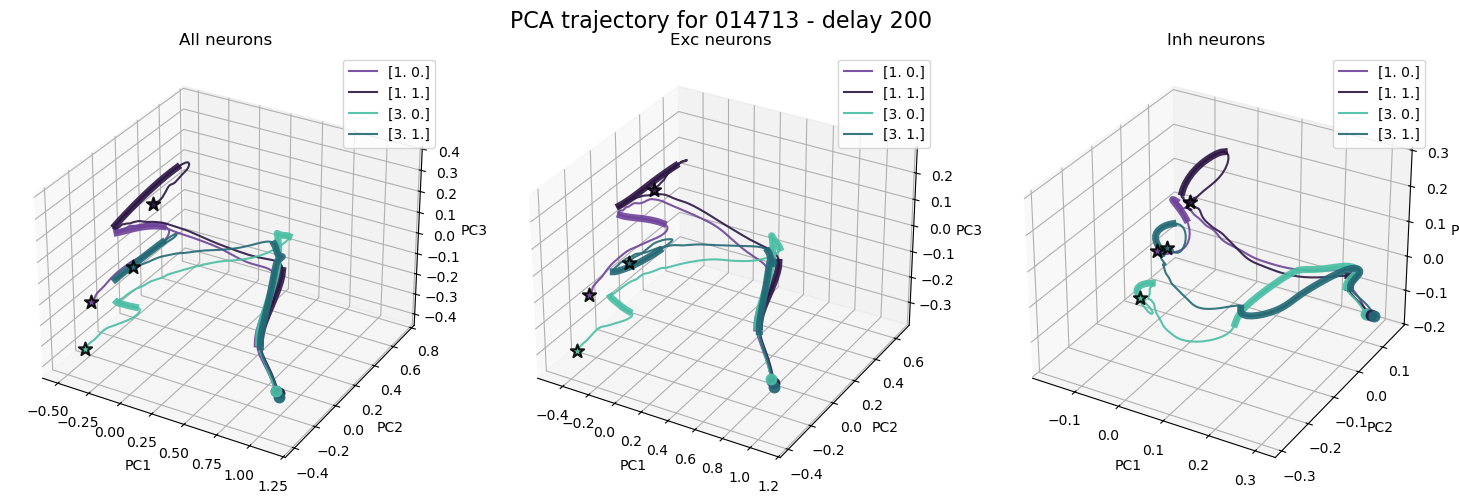

Accuracy for 014713: 0.81
PCA explained variance: [0.58010894 0.1629999  0.10869445], total: 0.8518032902756437
PCA explained variance: [0.58010894 0.1629999  0.10869445], total: 0.8518032902756437


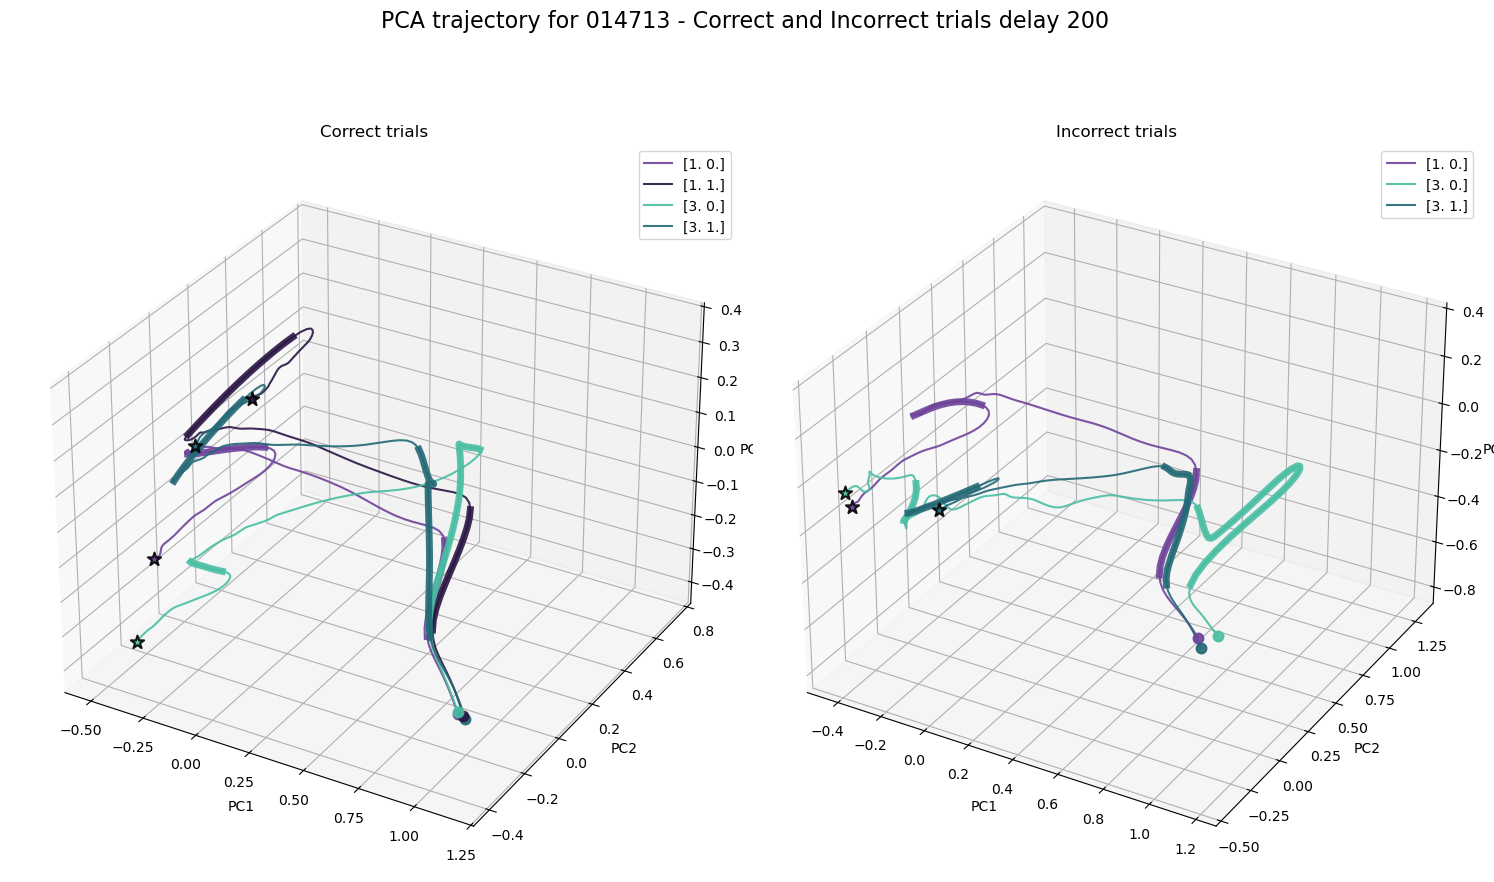

PCA explained variance: [0.59203234 0.15617441 0.10004162], total: 0.8482483706899332
PCA explained variance: [0.59956617 0.14823326 0.10749949], total: 0.8552989213117497
PCA explained variance: [0.58193622 0.18813949 0.10703945], total: 0.8771151632938645


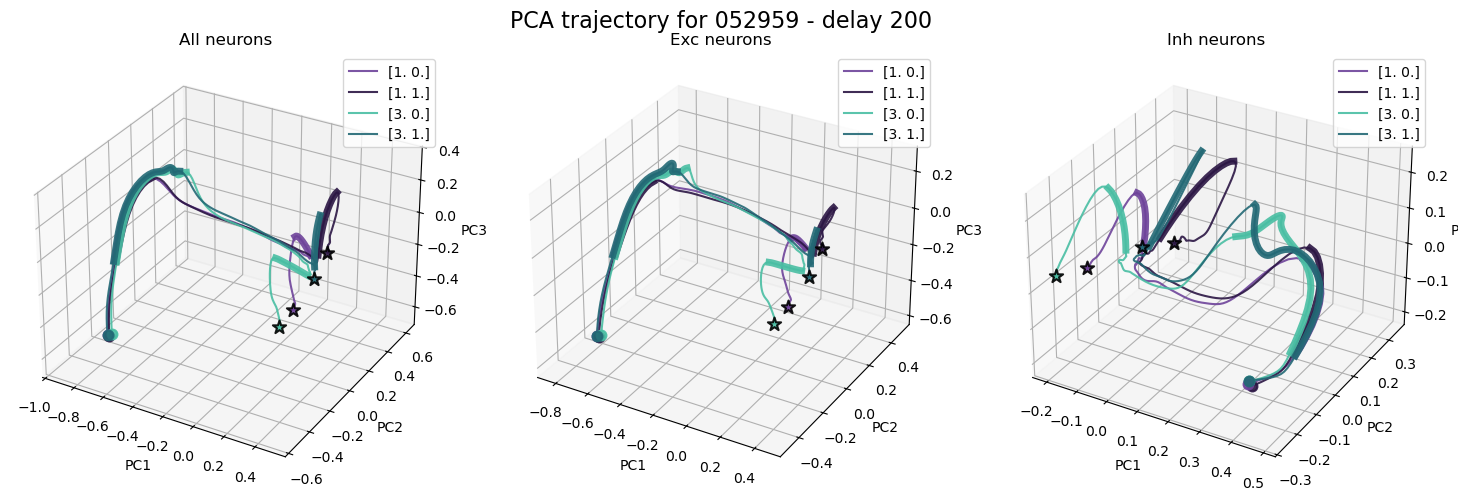

Accuracy for 052959: 0.81
PCA explained variance: [0.59203234 0.15617441 0.10004162], total: 0.8482483706899332
PCA explained variance: [0.59203234 0.15617441 0.10004162], total: 0.8482483706899332


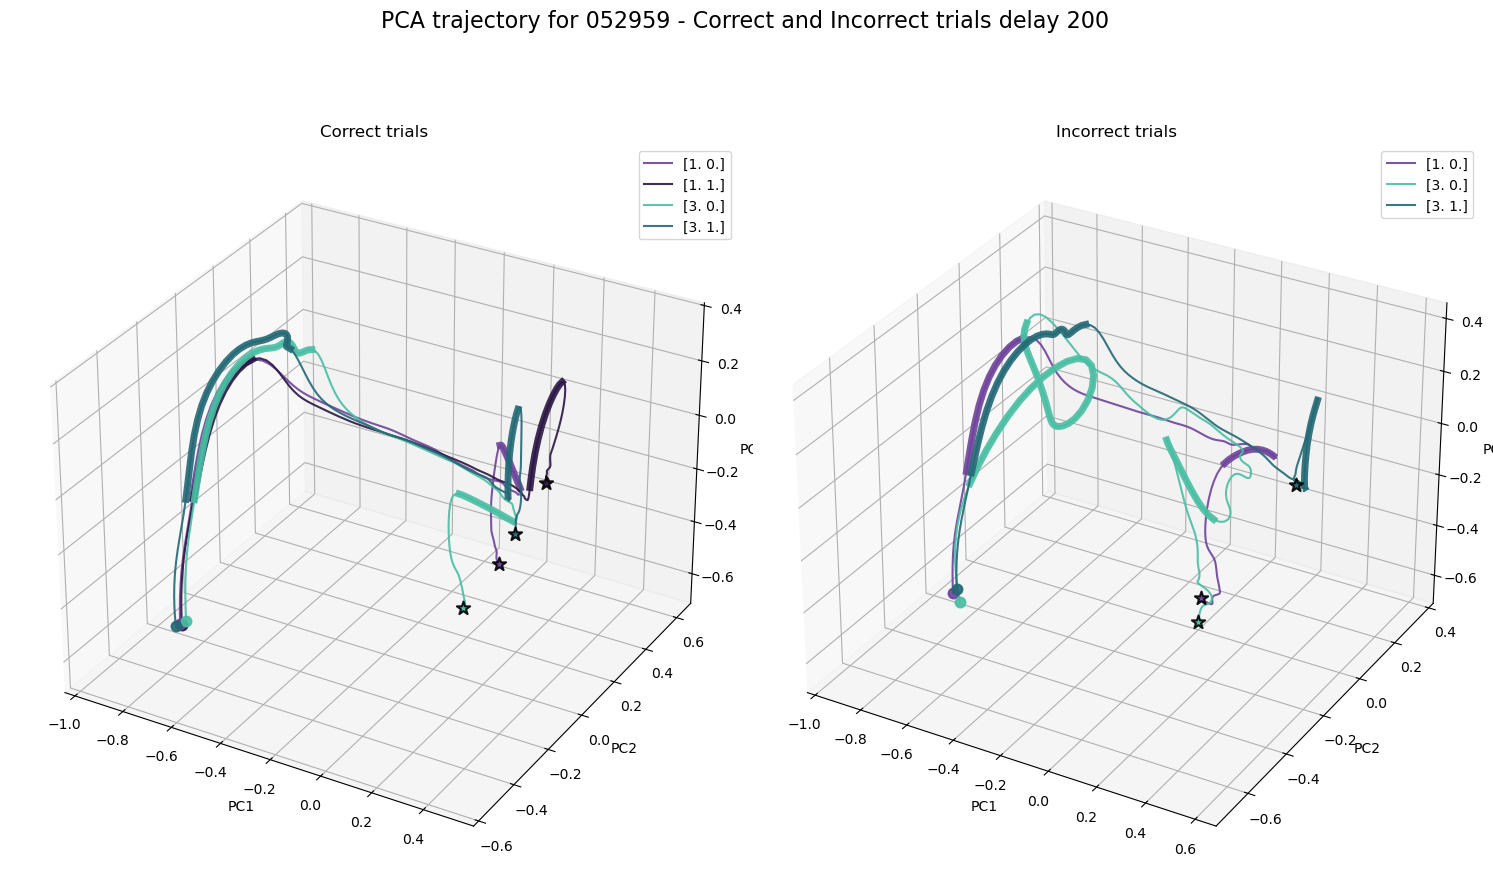

PCA explained variance: [0.58010147 0.18766908 0.09086542], total: 0.8586359698188826
PCA explained variance: [0.57300478 0.18289296 0.09155078], total: 0.8474485219553489
PCA explained variance: [0.61159488 0.20422245 0.09184153], total: 0.9076588589205916


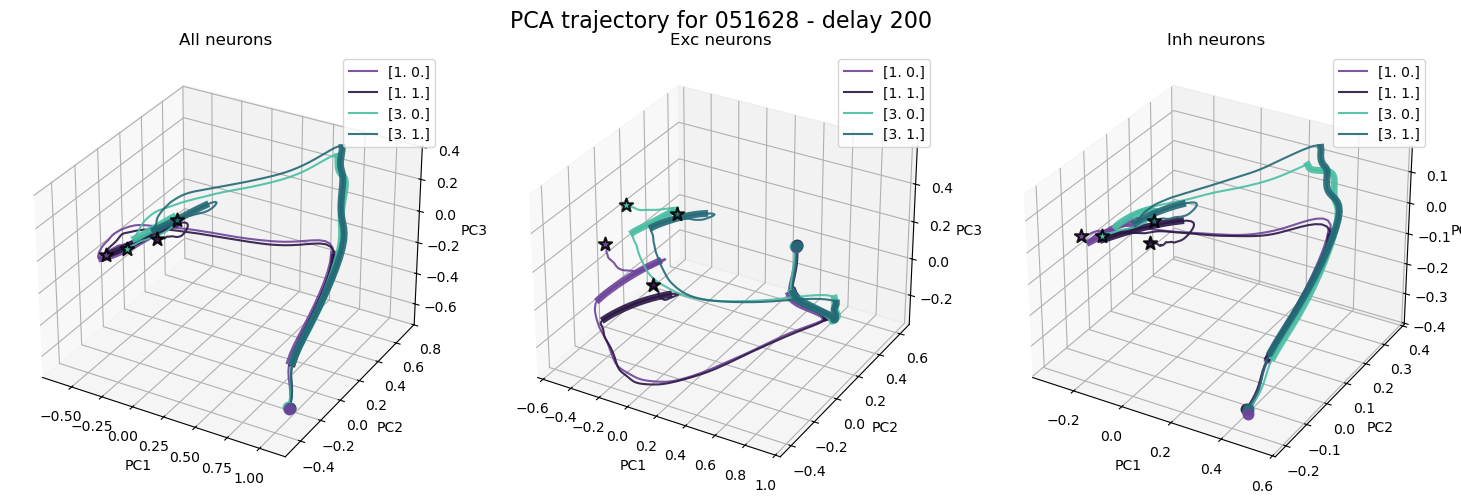

Accuracy for 051628: 0.81
PCA explained variance: [0.58010147 0.18766908 0.09086542], total: 0.8586359698188826
PCA explained variance: [0.58010147 0.18766908 0.09086542], total: 0.8586359698188826


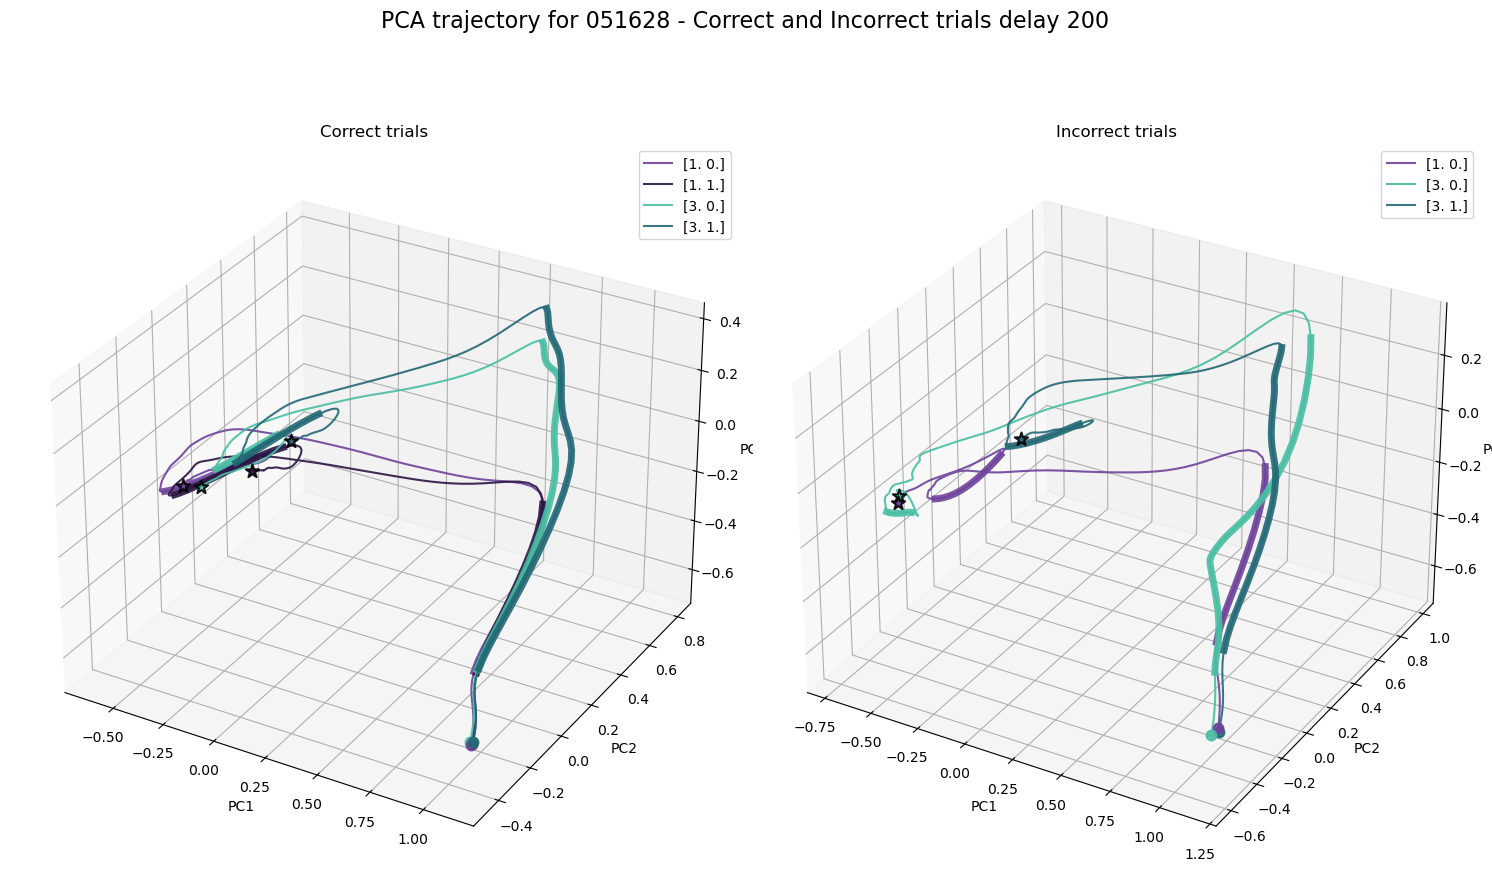

PCA explained variance: [0.58110359 0.20705533 0.07665867], total: 0.864817586853363
PCA explained variance: [0.59358024 0.21508422 0.06116638], total: 0.8698308396186147
PCA explained variance: [0.53319121 0.17223619 0.15338821], total: 0.8588156022465674


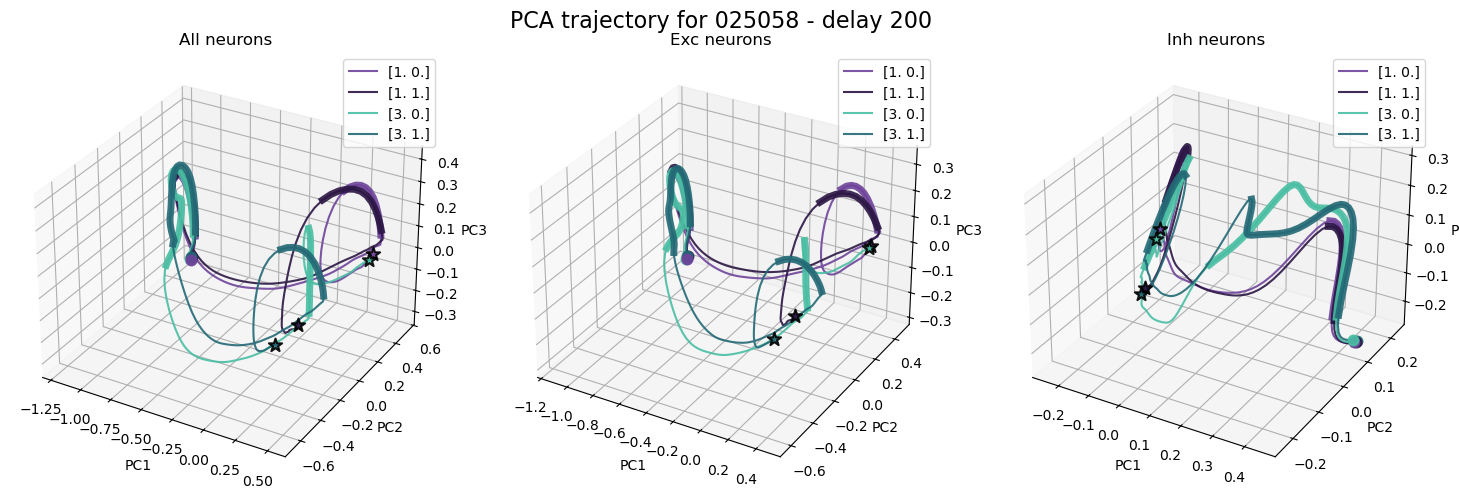

Accuracy for 025058: 0.81
PCA explained variance: [0.58110359 0.20705533 0.07665867], total: 0.864817586853363
PCA explained variance: [0.58110359 0.20705533 0.07665867], total: 0.864817586853363


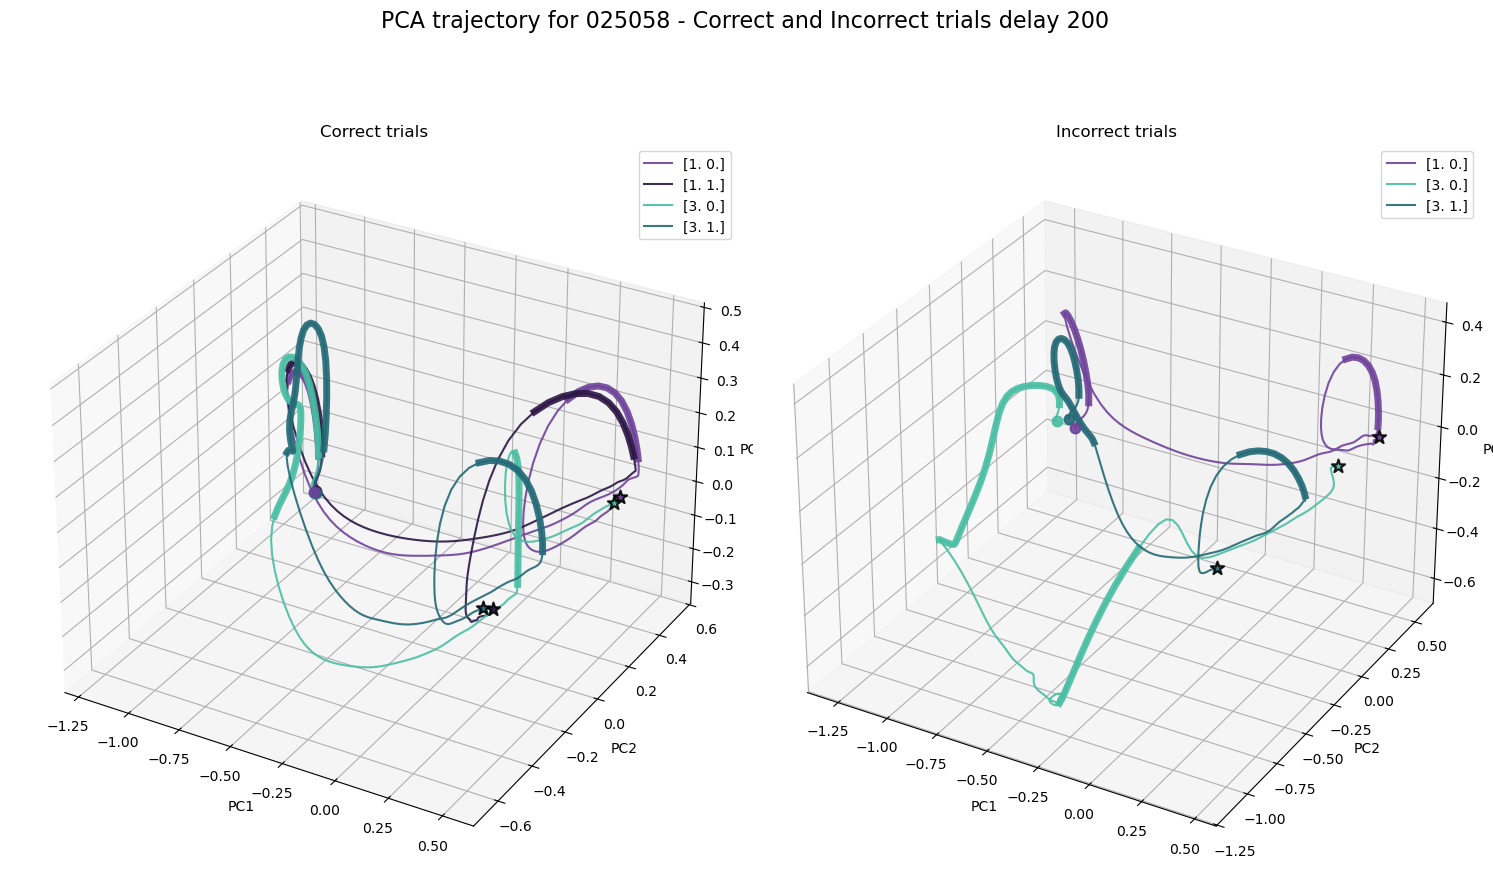

In [31]:
# across models

for i, model_name in enumerate(model_names):
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num,
                                            all_models_dir = all_models_dir, load_LFP=False)
    
    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132, projection='3d')
    ax3 = fig.add_subplot(133, projection='3d')
    _, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=None, rates_data=rates_data, cut_off=25, 
                    ds=2, sigma=5, ax=ax1, title='All neurons',
                    all_models_dir=all_models_dir)
    _, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=exc_ind, rates_data=rates_data, cut_off=25, 
                    ds=2, sigma=5, ax=ax2, title='Exc neurons',
                    all_models_dir=all_models_dir)
    _, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=inh_ind, rates_data=rates_data, cut_off=25,
                    ds=2, sigma=5, ax=ax3, title='Inh neurons',
                    all_models_dir=all_models_dir)
    plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    rates_corr = rates_data[trial_perfs == 1,:,:]
    rates_incorr = rates_data[trial_perfs == 0,:,:]

    trials_labels_corr = trial_labels[trial_perfs == 1]
    trials_labels_incorr = trial_labels[trial_perfs == 0]
    
    # plot correct and incorrect next to each other

    print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

    fig = plt.figure(figsize=(15, 10))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                    neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, 
                    ds=2, sigma=5,
                    cut_off=25, ax=ax1, title='Correct trials',
                    all_models_dir=all_models_dir)
    pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                    neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, 
                    ds=2, sigma=5,
                    cut_off=25, ax=ax2, title='Incorrect trials',
                    all_models_dir=all_models_dir)
    plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {200}', fontsize=16)
    plt.tight_layout()
    plt.show()##